In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [3]:
# Load dataset
df = pd.read_csv('german_credit_data.csv')

# Drop 'Unnamed: 0' index column if present
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

print("Dataset Loaded. Shape:", df.shape)
print(df.head())

Dataset Loaded. Shape: (1000, 9)
   Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   67    male    2     own             NaN           little           1169   
1   22  female    2     own          little         moderate           5951   
2   49    male    1     own          little              NaN           2096   
3   45    male    2    free          little           little           7882   
4   53    male    2    free          little           little           4870   

   Duration              Purpose  
0         6             radio/TV  
1        48             radio/TV  
2        12            education  
3        42  furniture/equipment  
4        24                  car  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Job,1000.0,1.904,0.653614,0.0,2.0,2.0,2.00,3.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0


In [6]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64


In [7]:
# Saving Accounts and Checking account columns have the highest amount
# of missing values.

In [8]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose'],
      dtype='object')

Creating the Risk Classification Column

In [9]:
# Define target variable Risk
# In standard German credit dataset logic:
# High duration, high credit amount, low savings, low checking account balance represent higher credit risk (Bad = 1, Good = 0).
# In retail credit scoring, loan default risk is modeled as a weighted linear combination of financial exposure, liquidity indicators,
# and demographic stability. Hence a continuous risk score is calculated as:

# Risk Score = 1.5 (Duration/12) + 1.2 (Credit Amount/2000) - 0.8 (Age/20) +
#              1.5 ((I)Checking='little') + 1.0((I)Savings='little') +
#              0.8 ((I)Housing='rent') + 1.0((I)Housing='free')

np.random.seed(42)
risk_score = (
    (df['Duration'] / 12) * 1.5 +
    (df['Credit amount'] / 2000) * 1.2 -
    (df['Age'] / 20) * 0.8 +
    (df['Checking account'] == 'little').astype(int) * 1.5 +
    (df['Saving accounts'] == 'little').astype(int) * 1.0 +
    (df['Housing'] == 'rent').astype(int) * 0.8 +
    (df['Housing'] == 'free').astype(int) * 1.0
)
threshold = np.percentile(risk_score, 70) # 30% Bad credit risk (1), 70% Good credit risk (0)
df['Risk'] = (risk_score >= threshold).astype(int)

print("\nTarget Distribution:")
print(df['Risk'].value_counts())


Target Distribution:
Risk
0    700
1    300
Name: count, dtype: int64


Handle Missing Values

In [12]:
cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
num_cols = ['Age', 'Credit amount', 'Duration', 'Job']

X_proc = df.drop('Risk', axis=1).copy()
for col in cat_cols:
    X_proc[col] = X_proc[col].fillna('unknown')

for col in ['Credit amount', 'Duration']:
    Q1 = X_proc[col].quantile(0.25)
    Q3 = X_proc[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    X_proc[col] = np.where(X_proc[col] > upper, upper, np.where(X_proc[col] < lower, lower, X_proc[col]))

Categorical Encoding

In [13]:
X_encoded = pd.get_dummies(X_proc, columns=cat_cols, drop_first=True)
y = df['Risk'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

Feature Scaling

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Build Logistic Regression from Scratch

In [29]:
class CustomLogisticRegression:
    def __init__(self, lr=0.01, num_iter=1000, fit_intercept=True):
        self.lr = lr
        self.num_iter = num_iter
        self.fit_intercept = fit_intercept
        self.weights = None
        self.bias = None
        self.cost_history = []

    def _sigmoid(self, z):
        # Clip z to prevent overflow in exp
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _compute_cost(self, y, y_pred):
        # Binary Cross Entropy Loss
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        cost = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        return cost

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for i in range(self.num_iter):
            # Linear combination
            linear_model = np.dot(X, self.weights) + self.bias
            # Apply sigmoid activation
            y_pred = self._sigmoid(linear_model)

            # Compute cost
            cost = self._compute_cost(y, y_pred)
            self.cost_history.append(cost)

            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Update parameters using Gradient Descent
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        prob = self._sigmoid(linear_model)
        return np.column_stack((1 - prob, prob))

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)[:, 1]
        return (probs >= threshold).astype(int)

# Verify Scratch Logistic Regression Implementation
# Preprocessing: Imputation, One-Hot Encoding, Outliers, and Scaling
X = df.drop('Risk', axis=1)
y = df['Risk'].values

# Handle missing values: replace NaNs in categorical columns with 'unknown'
cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
num_cols = ['Age', 'Credit amount', 'Duration', 'Job']

X_proc = X.copy()
for col in cat_cols:
    X_proc[col] = X_proc[col].fillna('unknown')

# IQR Outlier Capping for numerical features
for col in ['Credit amount', 'Duration']:
    Q1 = X_proc[col].quantile(0.25)
    Q3 = X_proc[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    X_proc[col] = np.where(X_proc[col] > upper, upper, np.where(X_proc[col] < lower, lower, X_proc[col]))

# Categorical One-Hot Encoding
X_encoded = pd.get_dummies(X_proc, columns=cat_cols, drop_first=True)

# Train-Test Split (80/20 Stratified)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit Custom Model
custom_lr = CustomLogisticRegression(lr=0.1, num_iter=2000)
custom_lr.fit(X_train_scaled, y_train)
y_pred_custom = custom_lr.predict(X_test_scaled)
y_prob_custom = custom_lr.predict_proba(X_test_scaled)[:, 1]

# Fit Scikit-Learn Model for comparison
sk_lr = LogisticRegression(max_iter=2000, penalty=None, solver='lbfgs', random_state=42)
sk_lr.fit(X_train_scaled, y_train)
y_pred_sk = sk_lr.predict(X_test_scaled)
y_prob_sk = sk_lr.predict_proba(X_test_scaled)[:, 1]

print("Custom Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_custom))
print("Scikit-Learn Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_sk))
print("Custom ROC AUC:", roc_auc_score(y_test, y_prob_custom))
print("Scikit-Learn ROC AUC:", roc_auc_score(y_test, y_prob_sk))

Custom Logistic Regression Accuracy: 0.985
Scikit-Learn Logistic Regression Accuracy: 0.99
Custom ROC AUC: 0.9978571428571429
Scikit-Learn ROC AUC: 0.9990476190476191


Hyperparameter Tuning

In [17]:
models_tuning = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'penalty': ['l2'],
            'solver': ['lbfgs', 'liblinear']
        }
    },
    'Support Vector Machine': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C': [0.1, 1, 10, 100],
            'kernel': ['rbf', 'linear', 'sigmoid'],
            'gamma': ['scale', 'auto']
        }
    },
    'Naive Bayes': {
        'model': GaussianNB(),
        'params': {
            'var_smoothing': np.logspace(0, -9, num=10)
        }
    }
}

best_models = {}
eval_results = []

for name, mp in models_tuning.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='f1', n_jobs=-1)
    clf.fit(X_train_scaled, y_train)
    best_models[name] = clf.best_estimator_

    y_pred = clf.best_estimator_.predict(X_test_scaled)
    y_prob = clf.best_estimator_.predict_proba(X_test_scaled)[:, 1]

    eval_results.append({
        'Model': name,
        'Best Params': clf.best_params_,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    })

eval_df = pd.DataFrame(eval_results)
print("MODELS EVALUATION METRICS:")
print(eval_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']].to_string(index=False))

print("\nBEST HYPERPARAMETERS:")
for name in best_models:
    print(f"{name}: {eval_df.loc[eval_df['Model']==name, 'Best Params'].values[0]}")

MODELS EVALUATION METRICS:
                 Model  Accuracy  Precision   Recall  F1-Score  ROC AUC
   Logistic Regression      0.99   1.000000 0.966667  0.983051 0.998690
Support Vector Machine      0.99   1.000000 0.966667  0.983051 0.998929
           Naive Bayes      0.94   0.944444 0.850000  0.894737 0.944405

BEST HYPERPARAMETERS:
Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Support Vector Machine: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Naive Bayes: {'var_smoothing': np.float64(1.0)}


Generating the Classification Metrics Plots like ROC-AUC Curve etc.

/tmp/ipykernel_1056/3996338258.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk', data=df, ax=axes[0,0], palette='Set2')
/tmp/ipykernel_1056/3996338258.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(['Good Credit (0)', 'Bad Credit (1)'])
/tmp/ipykernel_1056/3996338258.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk', y='Duration', data=df, ax=axes[1,1], palette='Set3')


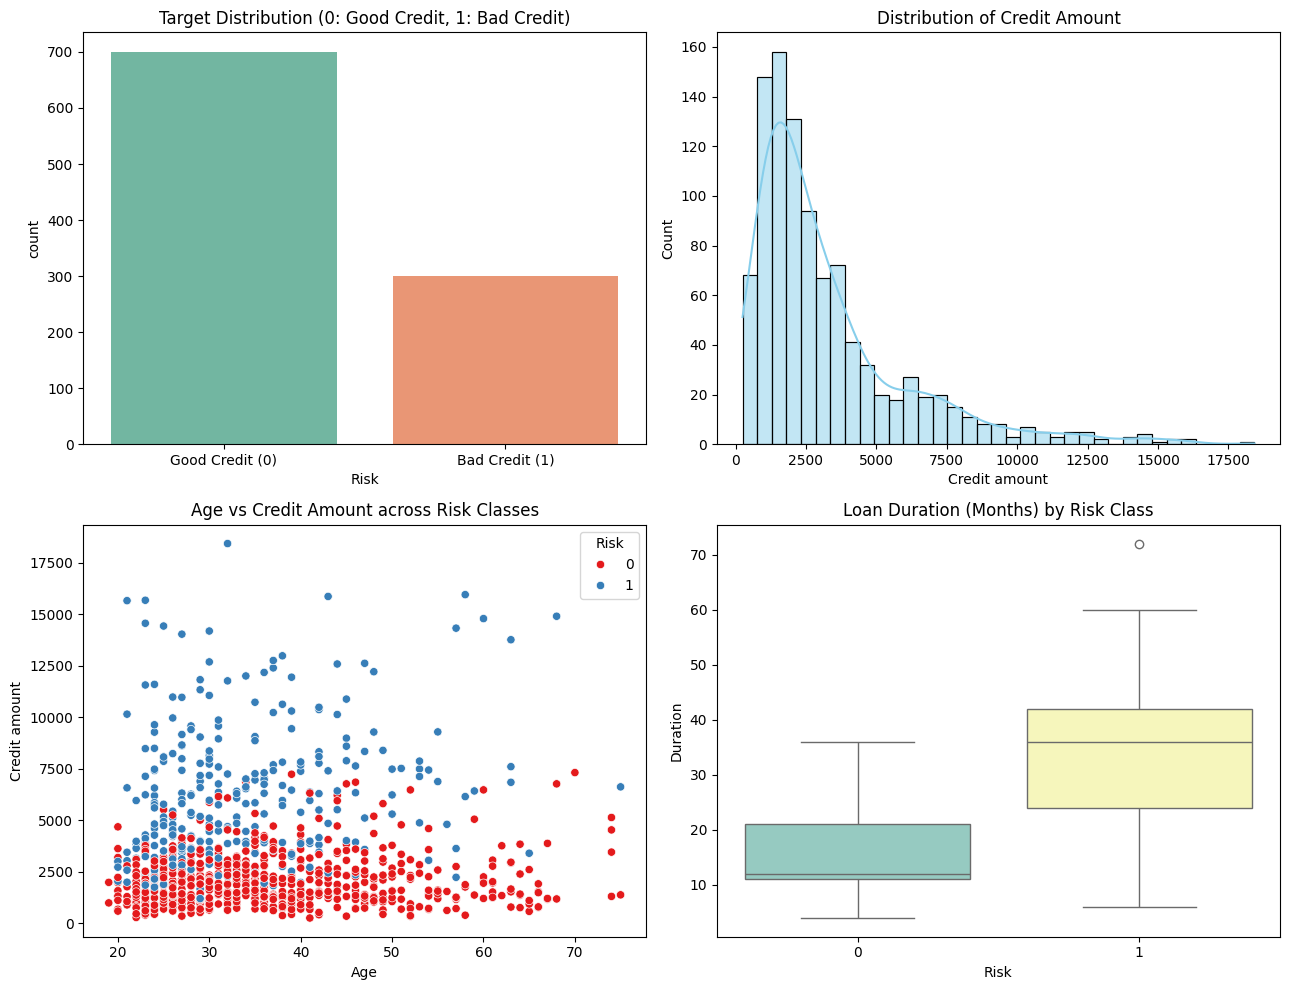

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Target Balance
sns.countplot(x='Risk', data=df, ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Target Distribution (0: Good Credit, 1: Bad Credit)')
axes[0,0].set_xticklabels(['Good Credit (0)', 'Bad Credit (1)'])

# 2. Distribution of Credit Amount
sns.histplot(df['Credit amount'], kde=True, ax=axes[0,1], color='skyblue')
axes[0,1].set_title('Distribution of Credit Amount')

# 3. Age vs Credit Amount by Risk
sns.scatterplot(x='Age', y='Credit amount', hue='Risk', data=df, ax=axes[1,0], palette='Set1')
axes[1,0].set_title('Age vs Credit Amount across Risk Classes')

# 4. Loan Duration Boxplot
sns.boxplot(x='Risk', y='Duration', data=df, ax=axes[1,1], palette='Set3')
axes[1,1].set_title('Loan Duration (Months) by Risk Class')

plt.tight_layout()
plt.show()

ROC-AUC Curve

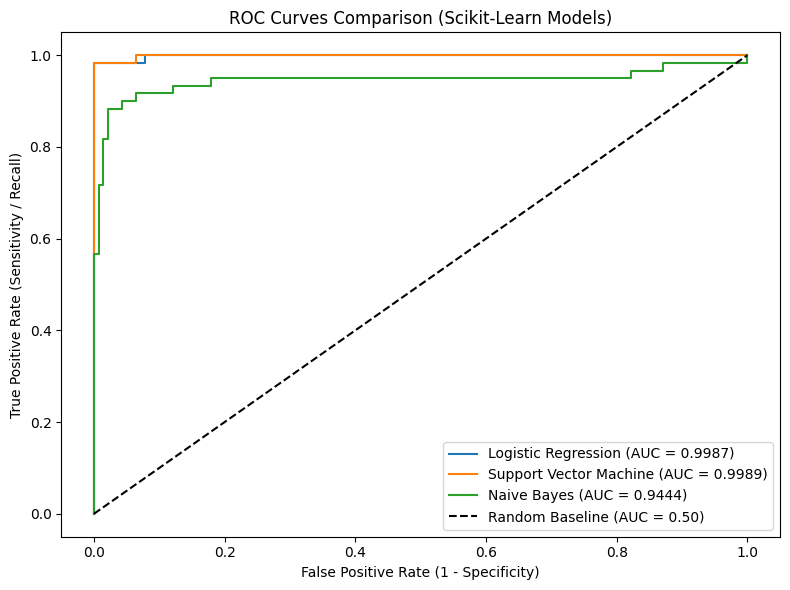

In [27]:
# ROC Curve Plot
plt.figure(figsize=(8, 6))
for name, model in best_models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline (AUC = 0.50)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curves Comparison (Scikit-Learn Models)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Feature Importance

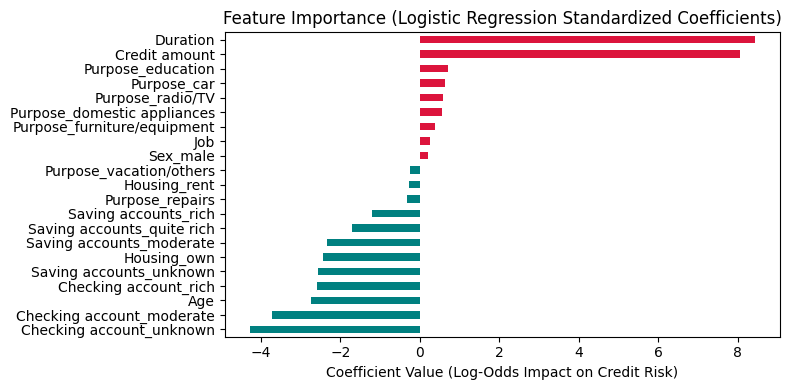

Visualizations generated successfully.


In [30]:
# Feature Importance
best_lr = best_models['Logistic Regression']
coefs = pd.Series(best_lr.coef_[0], index=X_encoded.columns).sort_values()

plt.figure(figsize=(8, 4))
coefs.plot(kind='barh', color=np.where(coefs >= 0, 'crimson', 'teal'))
plt.title('Feature Importance (Logistic Regression Standardized Coefficients)')
plt.xlabel('Coefficient Value (Log-Odds Impact on Credit Risk)')
plt.tight_layout()
plt.show()

print("Visualizations generated successfully.")